In this exampple we use a public SEG-Y file located in Amazon Web Services' Simple Storage Service (S3) to demonstrate **reading a remote dataset**. Let's again start by importing the required modules:

In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(1, '../')

import seisio
from time import time

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
log = logging.getLogger(__name__)

We use the S3 link `s3://open.source.geoscience/open_data/newzealand/Taranaiki_Basin/PARIHAKA-3D/Parihaka_PSTM_full_angle.sgy` to read the data. Note that the file is not downloaded first but read on demand directly from the object store. We need to tell S3 that we use anonymous access, otherwise credentials are required. They could also be passed to the storage backend using the `storage_options` parameter.

In [2]:
file = "s3://open.source.geoscience/open_data/newzealand/Taranaiki_Basin/PARIHAKA-3D/Parihaka_PSTM_full_angle.sgy"

sio = seisio.input(file, storage_options={"anon": True})

INFO: Input file: s3:/open.source.geoscience/open_data/newzealand/Taranaiki_Basin/PARIHAKA-3D/Parihaka_PSTM_full_angle.sgy
INFO: Input file is local? False
INFO: SEG-Y textual file header encoding looks to be 'EBCDIC' (best guess).
INFO: Input file endianess looks to be '>' (best guess).
INFO: SEG-Y revision (according to binary header): 1.0
INFO: Data sample format: 4-byte IBM floating-point.
INFO: SEG-Y fixed-trace-length flag is set in binary header.
INFO: Number of additional textual header records: 0.
INFO: Number of trailer stanza records: 0.
INFO: SEG-Y trace header extension 1 is not present.
INFO: Number of user-defined trace headers: 0
INFO: Byte offset of first trace relative to start of file: 3600 bytes.
INFO: Number of samples per data trace: 1168.
INFO: Sampling interval: 3000 (unit as per SEG-Y standard).
INFO: Number of data traces in file: 1038162.
INFO: Delay (on first trace): 0 (unit as per SEG-Y standard).
INFO: Coordinate scaler (on first trace): 1.
INFO: Elevation

There are 1'038'162 traces which matches the description of the data. Each trace has 1168 samples with a sampling interval of 3000 microseconds. The file size is:

In [3]:
log.info("File size in GiB: %.2f", sio.fsize / 1024**3)

INFO: File size in GiB: 4.75


which again matches the description (for details see SEG Wiki web page). The file identifies itself as SEG-Y revision 1. Let's check the textual and binary headers, then read 1000 traces from somewhere in the middle of the file:

In [4]:
txthead = sio.log_txthead()
binhead = sio.log_binhead()

start = 500000
ntraces = 1000

st = time()
traces = sio.read_batch_of_traces(start=start, ntraces=ntraces)
et = time()
log.info("Reading the traces took %.1f seconds.", et-st)

INFO: SEG-Y textual file header:
INFO: -------- BEGIN --------
C 1 3D VOLUME                                                                   
C 2 HEADER BYTE LOCATIONS AND TYPES:                                            
C 3     3D INLINE : 189-192 (4-BYTE INT)    3D CROSSLINE: 193-196 (4-BYTE INT)  
C 4     ENSEMBLE X: 181-184 (4-BYTE INT)    ENSEMBLE Y  : 185-188 (4-BYTE INT)  
C 5                                                                             
C 6 SAMPLES/TRACE     :       1168                                              
C 7 SAMPLE INTERVAL   :       3000 microseconds                                 
C 8 FIRST SAMPLE AT   :          0 ms                                           
C 9 VERTICAL DIMENSION: TWT (ms)                                                
C10 SAMPLE RECORDING FORMAT: IBM FLOATING POINT (4-BYTE)                        
C11                                                                             
C12                                           

This should take one or two seconds, depending on your internet connection. We can run some statistics on the traces we have just read:

In [5]:
thstat = sio.log_thstat(traces=traces)

INFO: Calculating trace header statistics.
INFO: Summary of trace header statistics (zeros excluded):
+--------+----------------+----------------+----------------+----------+----------------+----------------+
|        |            min |            max |           mean |      std |            25% |            75% |
|--------+----------------+----------------+----------------+----------+----------------+----------------|
| scalco |    1           |    1           |    1           |    0     |    1           |    1           |
| ns     | 1168           | 1168           | 1168           |    0     | 1168           | 1168           |
| dt     | 3000           | 3000           | 3000           |    0     | 3000           | 3000           |
| cdpx   |    2.57228e+06 |    2.58275e+06 |    2.57752e+06 | 3027.78  |    2.5749e+06  |    2.58014e+06 |
| cdpy   |    6.26431e+06 |    6.27111e+06 |    6.26771e+06 | 1966.29  |    6.26601e+06 |    6.26941e+06 |
| iline  | 2180           | 2180          

Now let's make a quick plot of the data we have just read:

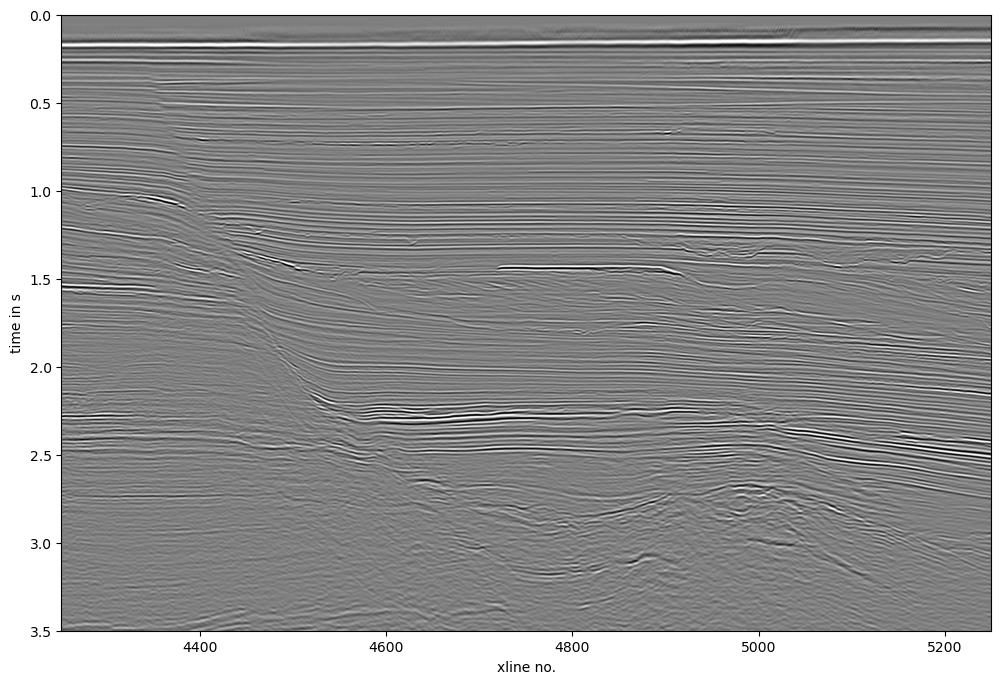

In [6]:
data = traces["data"]
xline = traces["xline"]
dt = sio.vsi * 1e-6
delay = sio.delay * 1e-3
t = np.arange(delay, delay+(sio.ns-1)*dt+dt/2, dt)
clip = np.percentile(data, 99.7)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
im = ax.imshow(data.T, aspect="auto", extent=[xline[0], xline[-1], t[-1], t[0]], cmap="grey", vmin=-clip, vmax=clip)
_ = ax.set_xlabel("xline no.")
_ = ax.set_ylabel("time in s")

Let's try to plot a time slice by randomly sampling the file. We will read 5000 random traces. 

In [7]:
rng = np.random.default_rng()
idx = np.sort(rng.choice(sio.nt, size=5000, replace=False))

st = time()
rng_traces = sio.read_traces(*idx)
et = time()
log.info("Reading the traces took %.1f seconds.", et-st)

INFO: Reading 5000 specific trace(s)...
INFO: Reading the traces took 83.3 seconds.


Now we extract the CMP x and y coordinates. As the scaling factor is one, no scaling of the coordinates is required.

In [8]:
cdpx = rng_traces["cdpx"]
cdpy = rng_traces["cdpy"]

Now we are in a position to plot a time slice using actual coordinates from the trace headers. Note that the slice has been significantly downsampled, i.e., the time slice is aliased. This is just for demonstration purpose in this example.

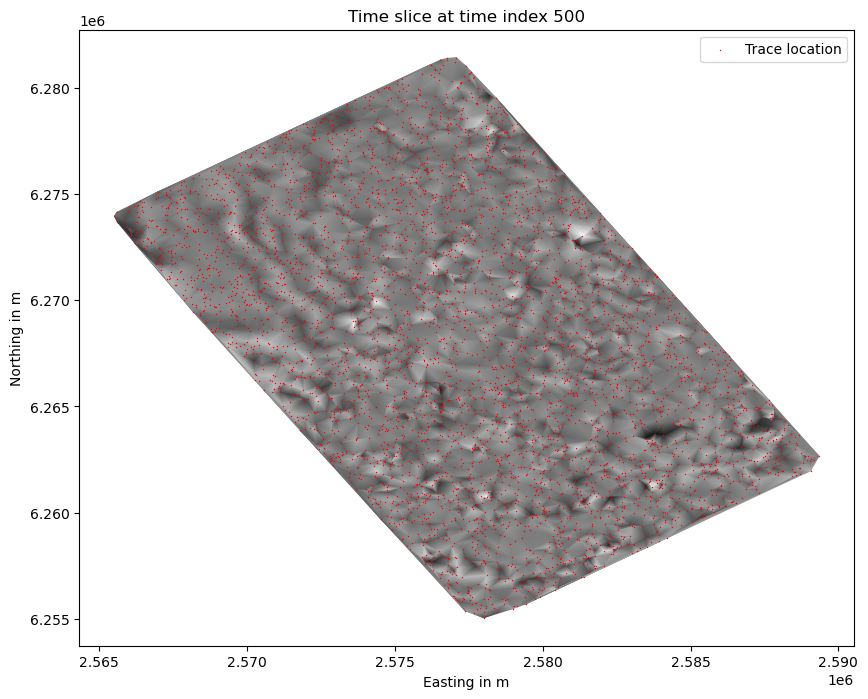

In [9]:
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))

t_idx = 500

x, y, t = (cdpx, cdpy, rng_traces["data"][:, t_idx])

_ = ax1.tripcolor(x, y, t, shading="gouraud", cmap="grey", vmin=-clip, vmax=clip)
_ = ax1.scatter(x, y, s=4, label="Trace location", color="red", linewidth=0, marker=".")
ax1.set_title(f"Time slice at time index {t_idx}")
_ = ax1.set_xlabel("Easting in m")
_ = ax1.set_ylabel("Northing in m")
_ = ax1.legend()